In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

# Unzip it
!unzip -q brain-tumor-mri-dataset.zip -d brain_tumor_data
!ls brain_tumor_data

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 235MB/s]

Testing  Training


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

# Check GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

--- Training Set ---
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

--- Testing Set ---
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


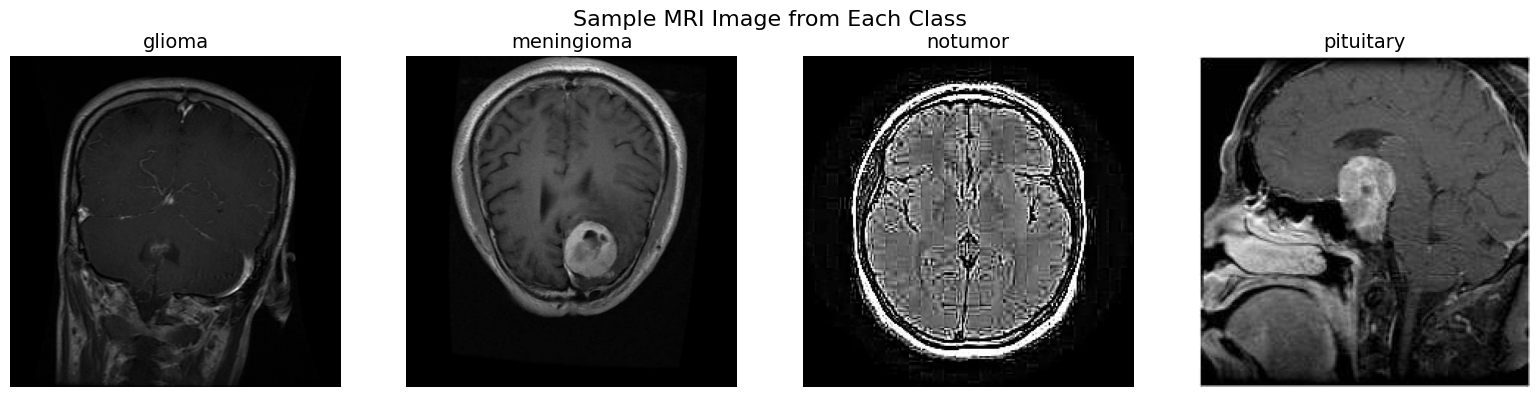

In [ ]:
TRAIN_DIR = "brain_tumor_data/Training"
TEST_DIR = "brain_tumor_data/Testing"

# See what classes we have
classes = sorted(os.listdir(TRAIN_DIR))
print(f"Classes: {classes}")

# Count images per class
print("\n--- Training Set ---")
for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {count} images")

print("\n--- Testing Set ---")
for cls in classes:
    count = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls}: {count} images")

# Display sample images from each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    img_path = os.path.join(TRAIN_DIR, cls, os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    img = Image.open(img_path)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(cls, fontsize=14)
    axes[i].axis("off")
plt.suptitle("Sample MRI Image from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# --- Hyperparameters (all in one place for easy tuning) ---
IMG_SIZE = 128          # Resize all images to 128x128
BATCH_SIZE = 32         # Number of images per training batch
LEARNING_RATE = 0.001   # How fast the model learns
NUM_EPOCHS = 20         # How many times to go through the whole dataset
VAL_SPLIT = 0.15        # 15% of training data used for validation

# Smoke test: 100 images/class (~400 before train/val split). Set False for full dataset training.
SMOKE_TEST = True
MAX_IMAGES_PER_CLASS = 100 if SMOKE_TEST else None

# --- Transforms ---
# Data augmentation for training (helps the model generalize)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),           # Randomly flip images
    transforms.RandomRotation(15),               # Randomly rotate ±15°
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Vary brightness/contrast
    transforms.ToTensor(),                        # Convert to tensor (0-1 range)
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # Normalize to [-1, 1]
                         std=[0.5, 0.5, 0.5]),
])

# No augmentation for validation/testing — just resize and normalize
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])


class BrainTumorDataset(Dataset):
    """Custom PyTorch Dataset for loading brain MRI images."""

    def __init__(self, root_dir, transform=None, max_per_class=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.images = []
        self.labels = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            names = sorted(
                f for f in os.listdir(cls_dir) if not f.startswith(".")
            )
            if max_per_class is not None:
                names = names[:max_per_class]
            for img_name in names:
                self.images.append(os.path.join(cls_dir, img_name))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")  # Ensure 3 channels
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# --- Create datasets ---
if MAX_IMAGES_PER_CLASS:
    print(
        f"Subset mode: up to {MAX_IMAGES_PER_CLASS} images per class "
        f"({len(os.listdir(TRAIN_DIR))} classes).\n"
    )

full_train_dataset = BrainTumorDataset(
    TRAIN_DIR, transform=train_transform, max_per_class=MAX_IMAGES_PER_CLASS
)
test_dataset = BrainTumorDataset(
    TEST_DIR, transform=test_transform, max_per_class=MAX_IMAGES_PER_CLASS
)

# Split training data into train + validation
val_size = int(VAL_SPLIT * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Override transform for validation subset (no augmentation)
val_dataset.dataset = BrainTumorDataset(
    TRAIN_DIR, transform=test_transform, max_per_class=MAX_IMAGES_PER_CLASS
)

print(f"Training samples:   {train_size}")
print(f"Validation samples: {val_size}")
print(f"Test samples:       {len(test_dataset)}")

# --- Create data loaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nBatches per epoch: {len(train_loader)}")

Training samples:   4760
Validation samples: 840
Test samples:       1600

Batches per epoch: 149


In [ ]:
class BrainTumorCNN(nn.Module):
    """
    Custom CNN for brain tumor classification.

    Architecture:
      3 convolutional blocks (each: Conv → BatchNorm → ReLU → MaxPool → Dropout)
      followed by a fully connected classifier head.

    This is NOT a pre-trained model — all weights are randomly initialized
    and trained entirely on our dataset.
    """

    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        # --- Convolutional Feature Extractor ---

        # Block 1: Input 3x128x128 → Output 32x64x64
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 128→64
            nn.Dropout2d(0.25),
        )

        # Block 2: 32x64x64 → 64x32x32
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64→32
            nn.Dropout2d(0.25),
        )

        # Block 3: 64x32x32 → 128x16x16
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32→16
            nn.Dropout2d(0.25),
        )

        # --- Classifier Head ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x


# --- Initialize the model ---
model = BrainTumorCNN(num_classes=4).to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:\n{model}")

Total parameters:     17,068,708
Trainable parameters: 17,068,708

Model architecture:
BrainTumorCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5)

In [ ]:
# --- Training ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0

print("Starting training...\n")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    val_acc = 100.0 * val_correct / val_total

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        save_msg = " ★ Saved best model!"
    else:
        save_msg = ""

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch + 1:2d}/{NUM_EPOCHS}]  "
        f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.1f}%  |  "
        f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.1f}%{save_msg}"
    )

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

In [ ]:
# --- Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(history["val_loss"], label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train Accuracy", linewidth=2)
ax2.plot(history["val_acc"], label="Val Accuracy", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- Test set evaluation ---
class_names = sorted(os.listdir(TEST_DIR))

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"Test Accuracy: {test_acc:.2f}%\n")
print("Classification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title(f"Confusion Matrix — Test Accuracy: {test_acc:.1f}%", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- Save checkpoint for inference / GitHub (download in Colab: files.download) ---
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "hyperparameters": {
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "num_epochs": NUM_EPOCHS,
        },
        "test_accuracy": float(test_acc),
    },
    "brain_tumor_classifier.pth",
)
print("Saved: brain_tumor_classifier.pth, training_curves.png, confusion_matrix.png")

# In Colab you can download:
# from google.colab import files
# files.download("brain_tumor_classifier.pth")